# 07 NLP Full-Text Resume Screening Experiment

This notebook extends the structured synthetic resume screening experiment by adding a full-text NLP screening layer. Structured synthetic resumes are rendered into realistic plain-text resumes using an LLM, then evaluated using semantic similarity to a software engineering manager job description.

The purpose is to test how screening behavior changes when resume data moves from structured features to full-text resume language. The experiment compares three rendering modes:

1. `with_proxies` — includes common age-correlated proxy fields such as graduation year, estimated career start year, total experience, and seniority signals.
2. `without_direct_age_proxies` — removes direct date-based proxies such as graduation year and estimated start year, while preserving experience, title, skills, and other role-relevant information.
3. `minimal_proxy` — removes a broader set of seniority- and age-correlated fields to create a reduced-leakage version of each resume.

The central question is not simply whether older candidates are favored or disfavored. The goal is to distinguish between two screening mechanisms:

- **Job-description similarity:** Does the resume match the stated requirements of the role?
- **Incumbent-profile similarity:** Does the resume resemble the profiles of people who have historically been hired or retained?

This distinction matters because experienced candidates may score highly when evaluated against a job description, while appearing less similar when compared against a younger or less senior incumbent workforce. This notebook focuses on the job-description similarity side of that contrast and is intended to be interpreted alongside the earlier structured callback and similarity experiments.

The notebook produces audit tables, NLP similarity summaries, screen-in rate summaries, figures, and a scored full-text resume dataset for follow-up analysis.

In [1]:
from pathlib import Path
import re
import json
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

ROOT = Path("..").resolve() if Path("../data").exists() else Path(".").resolve()
DATA_DIR = ROOT / "data"
EXPERIMENTS_DIR = DATA_DIR / "experiments"
REPORTS_DIR = ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ROOT

PosixPath('/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter')

## 1. Load full-text resume variants

This expects the generation script to have created the following files:

- `data/experiments/synthetic_resumes_balanced_1000_fulltext_with_proxies.csv`
- `data/experiments/synthetic_resumes_balanced_1000_fulltext_without_direct_age_proxies.csv`
- `data/experiments/synthetic_resumes_balanced_1000_fulltext_minimal_proxy.csv`

For quick testing, set `USE_SAMPLE_FILES = True` to load the 25-row sample files instead.

In [2]:
USE_SAMPLE_FILES = False

if USE_SAMPLE_FILES:
    file_template = "synthetic_resumes_fulltext_sample_{mode}.csv"
else:
    file_template = "synthetic_resumes_balanced_1000_fulltext_{mode}.csv"

modes = [
    "with_proxies",
    "without_direct_age_proxies",
    "minimal_proxy",
]

frames = []
missing = []

for mode in modes:
    path = EXPERIMENTS_DIR / file_template.format(mode=mode)
    if not path.exists():
        missing.append(path)
        continue
    df = pd.read_csv(path)
    df["generation_mode"] = mode
    df["source_file"] = path.name
    frames.append(df)

if missing:
    print("Missing files:")
    for path in missing:
        print(" -", path)
    raise FileNotFoundError("One or more generated full-text resume files are missing.")

fulltext = pd.concat(frames, ignore_index=True)
print(fulltext.shape)
fulltext[["candidate_id", "age_group", "generation_mode", "resume_text"]].head()

(3000, 68)


,candidate_id,age_group,generation_mode,resume_text
0,cand_009330,<30,with_proxies,"Emerson Chen\n\nSummary \nAspiring software engineer with a PhD and a strong foundation in programming and cloud technologies. Experienced in Python, JavaScript, and Go, with a focus on machine l..."
1,cand_007473,<30,with_proxies,"Riley Nguyen\n\nSummary \nMotivated software engineer with a foundational background in programming and cloud technologies. Eager to leverage skills in Python, JavaScript, and cloud platforms to ..."
2,cand_003605,<30,with_proxies,"Quinn Hall\n\nSummary \nMotivated software engineer with experience in Python, JavaScript, and cloud technologies. Proven ability to adapt and learn quickly, with a strong foundation in software ..."
3,cand_009055,<30,with_proxies,Alex Moore\n\nSummary \nDetail-oriented software engineer with nearly 4 years of experience in developing and maintaining applications. Proficient in a variety of programming languages and cloud ...
4,cand_005128,<30,with_proxies,"Quinn Martinez\n\nSummary \nAspiring software engineer with a PhD and a strong foundation in programming and cloud technologies. Proficient in Python, Java, AWS, Spark, and Terraform. Eager to co..."


## 2. Basic generation health checks

In [3]:
health_summary = (
    fulltext
    .assign(
        has_resume_text=fulltext["resume_text"].fillna("").str.strip().ne(""),
        has_generation_error=fulltext["generation_error"].fillna("").str.strip().ne(""),
        resume_char_count=fulltext["resume_text"].fillna("").str.len(),
        resume_word_count_generated=fulltext["resume_text"].fillna("").str.split().str.len(),
    )
    .groupby("generation_mode", observed=True)
    .agg(
        rows=("candidate_id", "count"),
        unique_candidates=("candidate_id", "nunique"),
        nonempty_resumes=("has_resume_text", "sum"),
        generation_error_rows=("has_generation_error", "sum"),
        mean_generated_words=("resume_word_count_generated", "mean"),
        median_generated_words=("resume_word_count_generated", "median"),
        min_generated_words=("resume_word_count_generated", "min"),
        max_generated_words=("resume_word_count_generated", "max"),
    )
    .reset_index()
)

health_summary.to_csv(TABLES_DIR / "nlp_fulltext_generation_health_summary.csv", index=False)
health_summary

,generation_mode,rows,unique_candidates,nonempty_resumes,generation_error_rows,mean_generated_words,median_generated_words,min_generated_words,max_generated_words
0,minimal_proxy,1000,1000,1000,0,73.885,74.0,51,130
1,with_proxies,1000,1000,1000,0,108.849,109.0,57,158
2,without_direct_age_proxies,1000,1000,1000,0,108.905,109.0,62,160


## 3. Leakage and placeholder audit

This checks for direct protected field leakage, internal experiment leakage, and placeholder artifacts from the LLM renderer.

In [4]:
audit_patterns = {
    "bracket_placeholder": r"\[[^\]]+\]",
    "unspecified_or_not_provided": r"\b(unspecified|not provided|details not provided)\b",
    "company_school_placeholder": r"\b(Company Name|School Name)\b",
    "url_placeholder": r"\b(GitHub URL present|Portfolio URL present|GitHub URL|Portfolio URL)\b",
    "numbered_certification": r"\bCertification\s+[0-9]+\b",
    "project_details_placeholder": r"\bProject details\b",
    "highest_degree_none": r"Highest Degree:\s*None",
    "protected_field_terms": r"\b(true_age|age_group|protected class|protected field|fairness analysis)\b",
    "outcome_label_terms": r"\b(callback|interview label|offer label|target label)\b",
    "explicit_age_phrase": r"\b[0-9]{2}\s*(years old|year-old)\b",
}

rows = []
for mode, df_mode in fulltext.groupby("generation_mode", observed=True):
    texts = df_mode["resume_text"].fillna("")
    for label, pattern in audit_patterns.items():
        mask = texts.str.contains(pattern, case=False, regex=True, na=False)
        rows.append({
            "generation_mode": mode,
            "audit_pattern": label,
            "hit_rows": int(mask.sum()),
            "hit_rate": float(mask.mean()),
        })

audit_summary = pd.DataFrame(rows)
audit_summary.to_csv(TABLES_DIR / "nlp_fulltext_leakage_placeholder_audit.csv", index=False)

audit_summary_pivot = audit_summary.pivot(
    index="audit_pattern",
    columns="generation_mode",
    values="hit_rows",
).fillna(0).astype(int)

audit_summary_pivot

/tmp/ipykernel_22718/1876984846.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = texts.str.contains(pattern, case=False, regex=True, na=False)


generation_mode,minimal_proxy,with_proxies,without_direct_age_proxies
audit_pattern,,,
bracket_placeholder,0,0,0
company_school_placeholder,0,0,0
explicit_age_phrase,0,0,0
highest_degree_none,0,0,0
numbered_certification,0,0,0
outcome_label_terms,0,0,0
project_details_placeholder,0,0,0
protected_field_terms,0,0,0
unspecified_or_not_provided,0,0,0


In [5]:
# Show examples only if there are audit hits.
for label, pattern in audit_patterns.items():
    hits = fulltext[fulltext["resume_text"].fillna("").str.contains(pattern, case=False, regex=True, na=False)]
    if len(hits):
        print("\n" + "=" * 90)
        print(label, "| rows:", len(hits))
        print("=" * 90)
        display(hits[["candidate_id", "age_group", "generation_mode", "resume_text"]].head(5))

/tmp/ipykernel_22718/1834748852.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hits = fulltext[fulltext["resume_text"].fillna("").str.contains(pattern, case=False, regex=True, na=False)]


## 4. Compare resume text length by mode and age group

This verifies that the rendering modes create meaningfully different text distributions and checks whether generated text length varies by age group.

In [6]:
fulltext["generated_word_count"] = fulltext["resume_text"].fillna("").str.split().str.len()
fulltext["generated_char_count"] = fulltext["resume_text"].fillna("").str.len()

length_by_mode_age = (
    fulltext
    .groupby(["generation_mode", "age_group"], observed=True)
    .agg(
        rows=("candidate_id", "count"),
        mean_words=("generated_word_count", "mean"),
        median_words=("generated_word_count", "median"),
        std_words=("generated_word_count", "std"),
    )
    .reset_index()
)

length_by_mode_age.to_csv(TABLES_DIR / "nlp_fulltext_length_by_mode_age.csv", index=False)
length_by_mode_age

,generation_mode,age_group,rows,mean_words,median_words,std_words
0,minimal_proxy,30-39,200,74.820,74.0,9.543742
1,minimal_proxy,40-49,200,75.185,75.0,7.989363
2,minimal_proxy,50-59,200,74.715,74.5,8.167454
3,minimal_proxy,60+,200,73.415,73.0,8.373371
4,minimal_proxy,<30,200,71.290,70.5,9.029594
5,with_proxies,30-39,200,108.510,108.0,14.202410
6,with_proxies,40-49,200,111.595,111.0,11.924426
7,with_proxies,50-59,200,112.695,112.0,12.725631
8,with_proxies,60+,200,114.295,113.0,13.075658
9,with_proxies,<30,200,97.150,96.0,15.883923


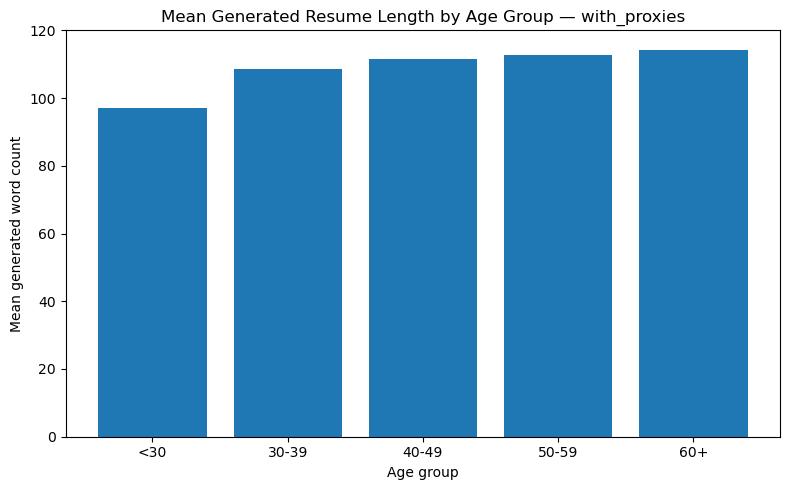

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/nlp_fulltext_mean_words_by_age_with_proxies.png


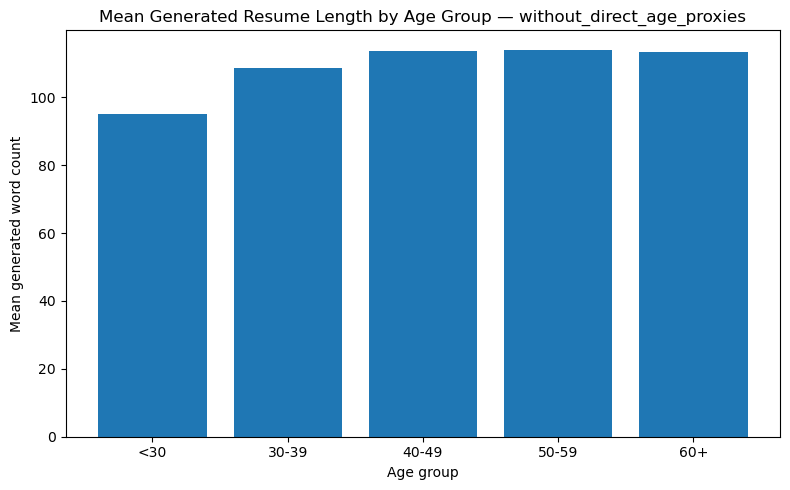

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/nlp_fulltext_mean_words_by_age_without_direct_age_proxies.png


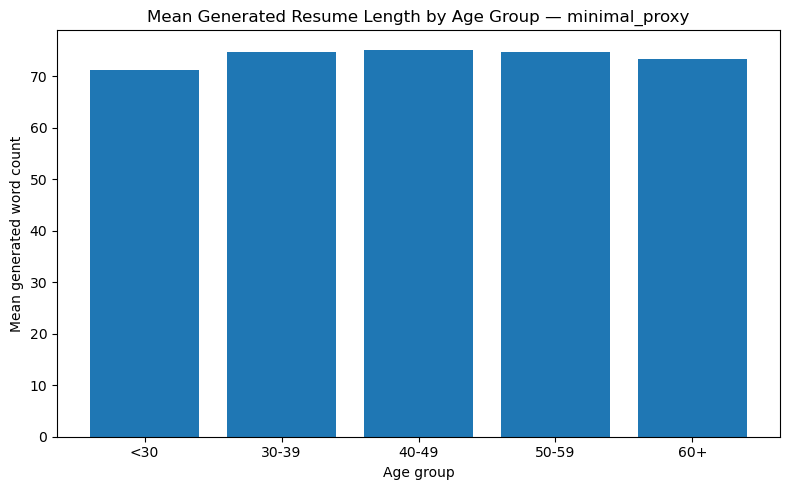

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/nlp_fulltext_mean_words_by_age_minimal_proxy.png


In [14]:
age_group_order = ["<30", "30-39", "40-49", "50-59", "60+"]

for mode in modes:
    plot_df = length_by_mode_age[length_by_mode_age["generation_mode"] == mode].copy()

    plot_df["age_group"] = pd.Categorical(
        plot_df["age_group"].astype(str),
        categories=age_group_order,
        ordered=True
    )

    plot_df = plot_df.sort_values("age_group")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(plot_df["age_group"].astype(str), plot_df["mean_words"])
    ax.set_title(f"Mean Generated Resume Length by Age Group — {mode}")
    ax.set_xlabel("Age group")
    ax.set_ylabel("Mean generated word count")
    fig.tight_layout()

    out = FIGURES_DIR / f"nlp_fulltext_mean_words_by_age_{mode}.png"
    fig.savefig(out, dpi=150)
    plt.show()
    print(out)

## 5. NLP screening setup

This section embeds each generated resume and compares it to a software engineering manager job description. The similarity score becomes a simple NLP screening score.

The notebook tries to use `sentence-transformers`. If the package or model is unavailable, install it first or run this section in an environment where the model is cached/downloadable.

In [8]:
JOB_DESCRIPTION = """
Software Engineering Manager, Infrastructure

We are looking for a hands-on engineering manager to lead a team building reliable, scalable cloud infrastructure and developer platforms. The role requires experience with distributed systems, production reliability, Kubernetes, Linux, cloud platforms, infrastructure as code, Python or Go, databases, incident response, and cross-functional technical leadership. The ideal candidate can mentor engineers, improve operational maturity, communicate clearly, and deliver measurable impact in production systems.
""".strip()

print(JOB_DESCRIPTION)

Software Engineering Manager, Infrastructure

We are looking for a hands-on engineering manager to lead a team building reliable, scalable cloud infrastructure and developer platforms. The role requires experience with distributed systems, production reliability, Kubernetes, Linux, cloud platforms, infrastructure as code, Python or Go, databases, incident response, and cross-functional technical leadership. The ideal candidate can mentor engineers, improve operational maturity, communicate clearly, and deliver measurable impact in production systems.


In [10]:
# Run embedding model.
# Recommended: sentence-transformers/all-MiniLM-L6-v2 for speed.

try:
    from sentence_transformers import SentenceTransformer
except ImportError as exc:
    raise ImportError(
        "sentence-transformers is required for this section. "
        "Install it with: pip install sentence-transformers"
    ) from exc

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

resume_texts = fulltext["resume_text"].fillna("").tolist()
resume_embeddings = embedding_model.encode(
    resume_texts,
    normalize_embeddings=True,
    show_progress_bar=True,
)
job_embedding = embedding_model.encode(
    [JOB_DESCRIPTION],
    normalize_embeddings=True,
)

fulltext["nlp_similarity_score"] = cosine_similarity(resume_embeddings, job_embedding).ravel()
fulltext[["candidate_id", "age_group", "generation_mode", "nlp_similarity_score"]].head()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

,candidate_id,age_group,generation_mode,nlp_similarity_score
0,cand_009330,<30,with_proxies,0.676448
1,cand_007473,<30,with_proxies,0.697966
2,cand_003605,<30,with_proxies,0.546535
3,cand_009055,<30,with_proxies,0.605519
4,cand_005128,<30,with_proxies,0.545869


## 6. Similarity score summaries by age group and mode

In [11]:
similarity_by_mode_age = (
    fulltext
    .groupby(["generation_mode", "age_group"], observed=True)
    .agg(
        rows=("candidate_id", "count"),
        mean_similarity=("nlp_similarity_score", "mean"),
        median_similarity=("nlp_similarity_score", "median"),
        std_similarity=("nlp_similarity_score", "std"),
        min_similarity=("nlp_similarity_score", "min"),
        max_similarity=("nlp_similarity_score", "max"),
    )
    .reset_index()
)

similarity_by_mode_age.to_csv(TABLES_DIR / "nlp_similarity_by_mode_age.csv", index=False)
similarity_by_mode_age

,generation_mode,age_group,rows,mean_similarity,median_similarity,std_similarity,min_similarity,max_similarity
0,minimal_proxy,30-39,200,0.586425,0.588392,0.049105,0.443737,0.722817
1,minimal_proxy,40-49,200,0.605973,0.605988,0.056646,0.441851,0.758800
2,minimal_proxy,50-59,200,0.632511,0.639651,0.060118,0.479903,0.776757
3,minimal_proxy,60+,200,0.636500,0.644970,0.057631,0.439840,0.781052
4,minimal_proxy,<30,200,0.587122,0.593656,0.047935,0.447763,0.698535
5,with_proxies,30-39,200,0.603406,0.605165,0.051067,0.460653,0.728836
6,with_proxies,40-49,200,0.630465,0.633557,0.055223,0.442848,0.772015
7,with_proxies,50-59,200,0.650832,0.653823,0.053302,0.506653,0.756989
8,with_proxies,60+,200,0.640422,0.641610,0.055021,0.444504,0.784266
9,with_proxies,<30,200,0.594561,0.595779,0.048015,0.466537,0.725791


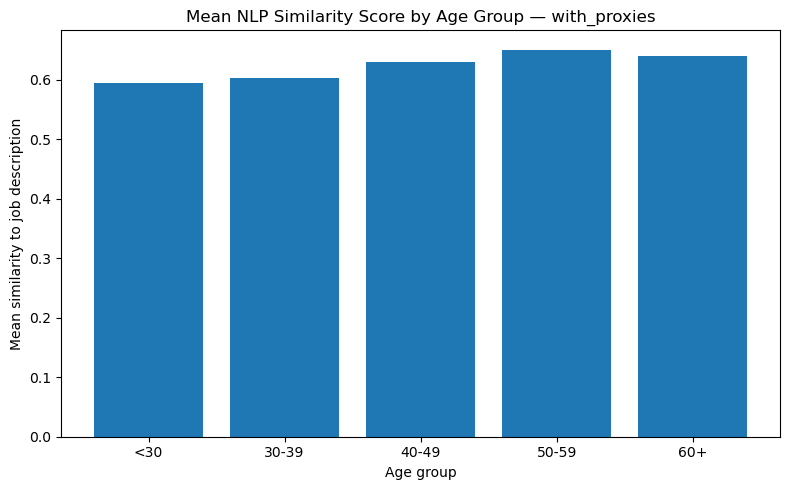

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/nlp_similarity_by_age_with_proxies.png


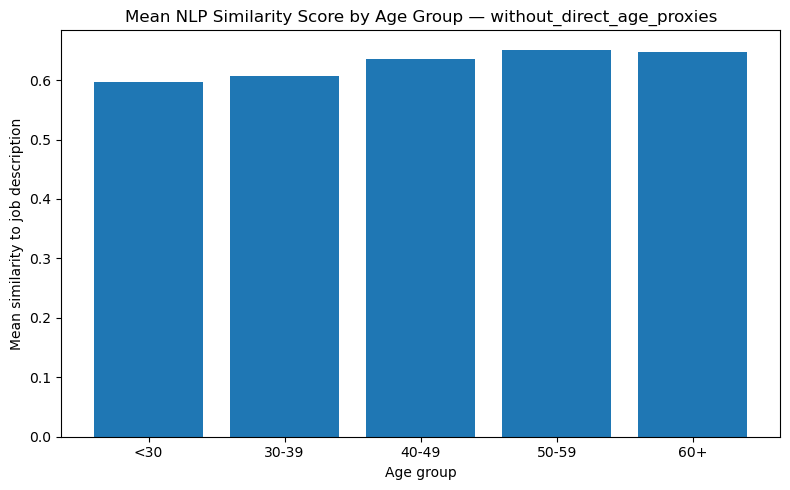

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/nlp_similarity_by_age_without_direct_age_proxies.png


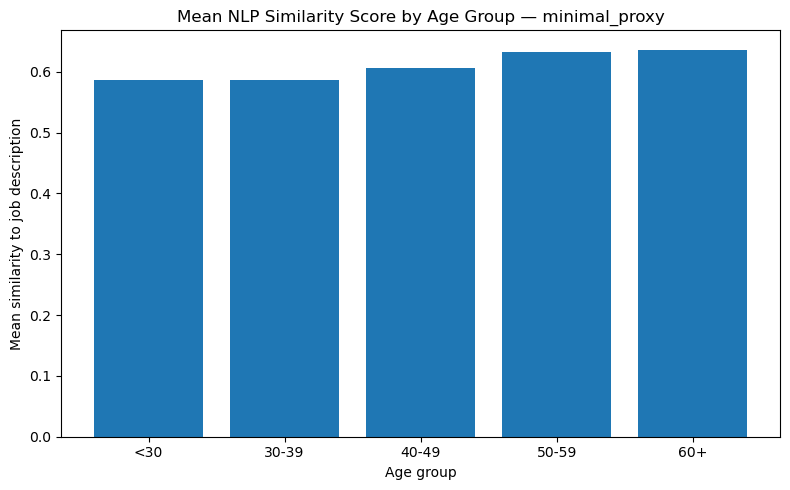

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/nlp_similarity_by_age_minimal_proxy.png


In [15]:
for mode in modes:
    plot_df = similarity_by_mode_age[
        similarity_by_mode_age["generation_mode"] == mode
    ].copy()

    plot_df["age_group"] = pd.Categorical(
        plot_df["age_group"].astype(str),
        categories=age_group_order,
        ordered=True
    )

    plot_df = plot_df.sort_values("age_group")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(plot_df["age_group"].astype(str), plot_df["mean_similarity"])
    ax.set_title(f"Mean NLP Similarity Score by Age Group — {mode}")
    ax.set_xlabel("Age group")
    ax.set_ylabel("Mean similarity to job description")
    fig.tight_layout()

    out = FIGURES_DIR / f"nlp_similarity_by_age_{mode}.png"
    fig.savefig(out, dpi=150)
    plt.show()
    print(out)

### Interpretation: Similarity Scores

The semantic similarity results show that resumes from older age groups generally score higher against the software engineering manager job description. This pattern is consistent across the three full-text generation modes.

This suggests that, when the comparison target is the job description itself, senior candidates are not disadvantaged by the NLP similarity model. Their resumes tend to contain more experience, broader technical coverage, leadership signals, and evidence of role-relevant accomplishments, all of which increase semantic match to the job description.

This is an important contrast with screening systems that compare candidates to existing employees or historical hires. A job-description similarity model asks whether the candidate matches the role. An incumbent-profile similarity model asks whether the candidate resembles people already in the organization. Those two objectives can produce very different fairness outcomes.


## 7. Screen-rate analysis using within-mode threshold

For each generation mode, this section marks the top-scoring resumes as screened in. The default screen rate is 45%, matching the synthetic label generation approach that used a thresholded score.

In [16]:
SCREEN_RATE = 0.45

fulltext["nlp_screened_in"] = False
fulltext["nlp_similarity_threshold"] = np.nan

for mode, idx in fulltext.groupby("generation_mode", observed=True).groups.items():
    mode_scores = fulltext.loc[idx, "nlp_similarity_score"]
    threshold = mode_scores.quantile(1 - SCREEN_RATE)
    fulltext.loc[idx, "nlp_similarity_threshold"] = threshold
    fulltext.loc[idx, "nlp_screened_in"] = mode_scores >= threshold

screen_rates = (
    fulltext
    .groupby(["generation_mode", "age_group"], observed=True)
    .agg(
        rows=("candidate_id", "count"),
        screened_in=("nlp_screened_in", "sum"),
        screen_rate=("nlp_screened_in", "mean"),
        mean_similarity=("nlp_similarity_score", "mean"),
    )
    .reset_index()
)

screen_rates.to_csv(TABLES_DIR / "nlp_screen_rates_by_mode_age.csv", index=False)
screen_rates

,generation_mode,age_group,rows,screened_in,screen_rate,mean_similarity
0,minimal_proxy,30-39,200,53,0.265,0.586425
1,minimal_proxy,40-49,200,84,0.420,0.605973
2,minimal_proxy,50-59,200,126,0.630,0.632511
3,minimal_proxy,60+,200,129,0.645,0.636500
4,minimal_proxy,<30,200,58,0.290,0.587122
5,with_proxies,30-39,200,61,0.305,0.603406
6,with_proxies,40-49,200,102,0.510,0.630465
7,with_proxies,50-59,200,128,0.640,0.650832
8,with_proxies,60+,200,115,0.575,0.640422
9,with_proxies,<30,200,44,0.220,0.594561


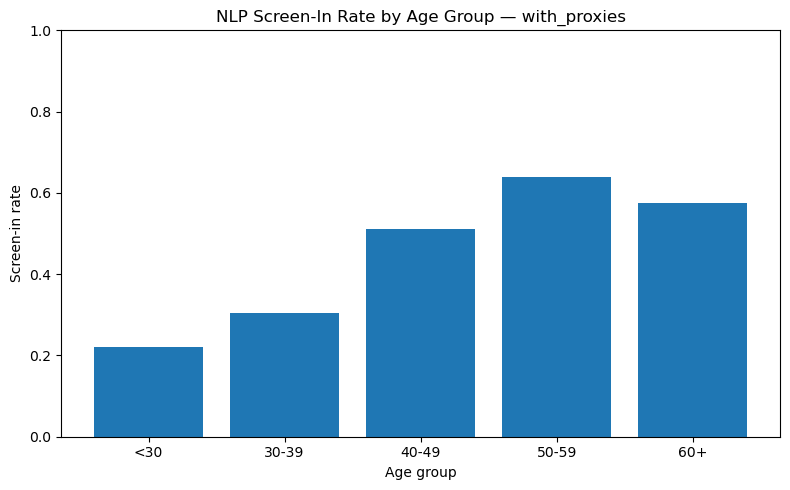

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/nlp_screen_rate_by_age_with_proxies.png


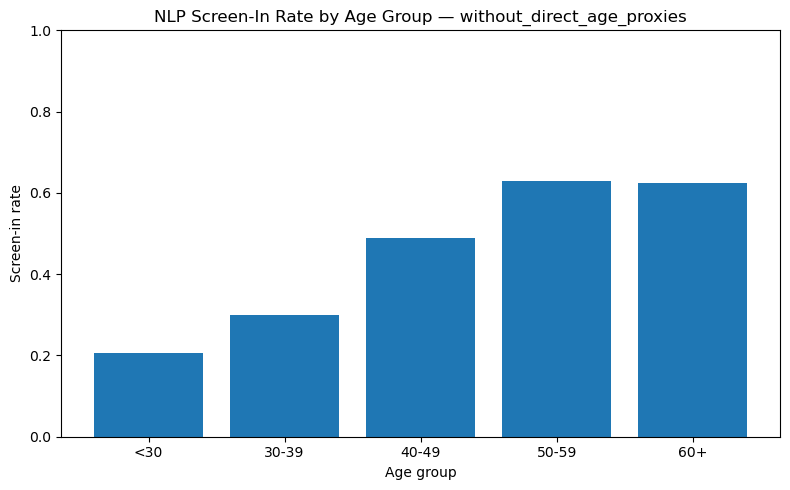

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/nlp_screen_rate_by_age_without_direct_age_proxies.png


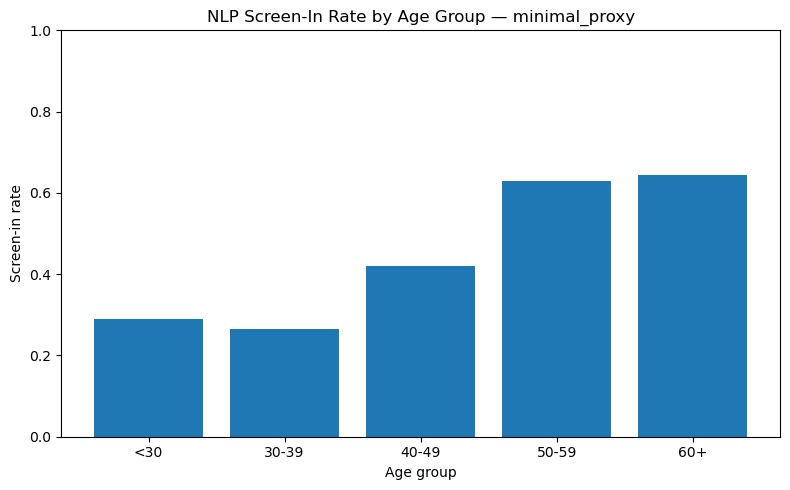

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures/nlp_screen_rate_by_age_minimal_proxy.png


In [18]:
for mode in modes:
    plot_df = screen_rates[screen_rates["generation_mode"] == mode].copy()

    plot_df["age_group"] = pd.Categorical(
        plot_df["age_group"].astype(str),
        categories=age_group_order,
        ordered=True
    )

    plot_df = plot_df.sort_values("age_group")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(plot_df["age_group"].astype(str), plot_df["screen_rate"])
    ax.set_title(f"NLP Screen-In Rate by Age Group — {mode}")
    ax.set_xlabel("Age group")
    ax.set_ylabel("Screen-in rate")
    ax.set_ylim(0, 1)
    fig.tight_layout()

    out = FIGURES_DIR / f"nlp_screen_rate_by_age_{mode}.png"
    fig.savefig(out, dpi=150)
    plt.show()
    print(out)

### Interpretation: Screen-In Rates

The screen-in rate analysis makes the similarity pattern more visible. Using a within-mode threshold, older age groups are screened in at higher rates than younger age groups across the generated full-text resume variants.

This does not imply that the model is detecting age directly. The generated resumes do not include explicit age fields, and the audit checks found no direct protected-field leakage. Instead, the model appears to reward job-relevant signals that are correlated with age in the synthetic data: experience, seniority, leadership, technical breadth, and resume richness.

The result supports a nuanced interpretation. If the screening task is framed as matching a resume to the job description, senior candidates should often perform well. The risk emerges when AI-assisted screening shifts from job-description relevance to similarity with historical hiring patterns or existing employee profiles.


## 8. Compare NLP screening to original synthetic callback label

This is not a model accuracy test in the strict sense. The original `callback` label was generated from structured data with a specific bias mechanism. The NLP screen-in flag is a separate screening mechanism based on full-text similarity to a job description.

Still, comparing them helps determine whether the full-text NLP representation reproduces, amplifies, or dampens the original group-level pattern.

In [19]:
if "callback" in fulltext.columns:
    # CSV may load booleans as bool or object. Normalize carefully.
    callback_bool = fulltext["callback"].astype(str).str.lower().map({"true": True, "false": False})
    fulltext["callback_bool"] = callback_bool

    callback_comparison = (
        fulltext
        .groupby(["generation_mode", "age_group"], observed=True)
        .agg(
            rows=("candidate_id", "count"),
            original_callback_rate=("callback_bool", "mean"),
            nlp_screen_rate=("nlp_screened_in", "mean"),
            mean_similarity=("nlp_similarity_score", "mean"),
        )
        .reset_index()
    )

    callback_comparison["screen_minus_callback"] = (
        callback_comparison["nlp_screen_rate"] - callback_comparison["original_callback_rate"]
    )

    callback_comparison.to_csv(TABLES_DIR / "nlp_vs_original_callback_by_mode_age.csv", index=False)
    display(callback_comparison)
else:
    print("No callback column found; skipping callback comparison.")

,generation_mode,age_group,rows,original_callback_rate,nlp_screen_rate,mean_similarity,screen_minus_callback
0,minimal_proxy,30-39,200,0.710,0.265,0.586425,-0.445
1,minimal_proxy,40-49,200,0.435,0.420,0.605973,-0.015
2,minimal_proxy,50-59,200,0.185,0.630,0.632511,0.445
3,minimal_proxy,60+,200,0.110,0.645,0.636500,0.535
4,minimal_proxy,<30,200,0.555,0.290,0.587122,-0.265
5,with_proxies,30-39,200,0.710,0.305,0.603406,-0.405
6,with_proxies,40-49,200,0.435,0.510,0.630465,0.075
7,with_proxies,50-59,200,0.185,0.640,0.650832,0.455
8,with_proxies,60+,200,0.110,0.575,0.640422,0.465
9,with_proxies,<30,200,0.555,0.220,0.594561,-0.335


## 9. Within-candidate mode deltas

This section compares the same candidate across generation modes. This is useful because each candidate has three rendered versions, so mode effects can be compared while holding the structured candidate constant.

In [20]:
wide_scores = fulltext.pivot_table(
    index=["candidate_id", "age_group"],
    columns="generation_mode",
    values="nlp_similarity_score",
    aggfunc="first",
).reset_index()

if {"with_proxies", "without_direct_age_proxies", "minimal_proxy"}.issubset(wide_scores.columns):
    wide_scores["delta_with_vs_without"] = wide_scores["with_proxies"] - wide_scores["without_direct_age_proxies"]
    wide_scores["delta_without_vs_minimal"] = wide_scores["without_direct_age_proxies"] - wide_scores["minimal_proxy"]
    wide_scores["delta_with_vs_minimal"] = wide_scores["with_proxies"] - wide_scores["minimal_proxy"]

    delta_summary = (
        wide_scores
        .groupby("age_group", observed=True)
        .agg(
            rows=("candidate_id", "count"),
            mean_delta_with_vs_without=("delta_with_vs_without", "mean"),
            mean_delta_without_vs_minimal=("delta_without_vs_minimal", "mean"),
            mean_delta_with_vs_minimal=("delta_with_vs_minimal", "mean"),
        )
        .reset_index()
    )

    wide_scores.to_csv(TABLES_DIR / "nlp_similarity_within_candidate_mode_deltas.csv", index=False)
    delta_summary.to_csv(TABLES_DIR / "nlp_similarity_mode_delta_summary_by_age.csv", index=False)
    display(delta_summary)
else:
    print("Not all three modes available; skipping within-candidate delta analysis.")

,age_group,rows,mean_delta_with_vs_without,mean_delta_without_vs_minimal,mean_delta_with_vs_minimal
0,30-39,200,-0.002974,0.019955,0.016981
1,40-49,200,-0.004809,0.029302,0.024493
2,50-59,200,-0.000274,0.018594,0.018321
3,60+,200,-0.006125,0.010047,0.003922
4,<30,200,-0.002676,0.010115,0.007438


### Interpretation: Effect of Removing Direct Age Proxies

The mode-delta analysis shows that removing direct date-based proxies such as graduation year and estimated start year does not materially change the NLP similarity pattern. The `with_proxies` and `without_direct_age_proxies` conditions produce very similar similarity scores and screen-in rates.

This suggests that direct date fields are not the main driver of the NLP result. Instead, the model is responding to broader resume content that remains after those fields are removed, including title, skills, experience level, leadership signals, and technical breadth.

The `minimal_proxy` condition reduces the amount of seniority-related information available to the model, which generally lowers resume richness and similarity scores. However, the age-group pattern does not disappear entirely. This indicates that age-correlated information is distributed across many resume features, not isolated in a single field such as graduation year.

## 10. Save scored dataset

The scored dataset is useful for follow-up analysis, additional plots, and README tables.

In [21]:
scored_path = EXPERIMENTS_DIR / "synthetic_resumes_balanced_1000_fulltext_scored.csv"
if USE_SAMPLE_FILES:
    scored_path = EXPERIMENTS_DIR / "synthetic_resumes_fulltext_sample_scored.csv"

fulltext.to_csv(scored_path, index=False)
print(scored_path)

/home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/data/experiments/synthetic_resumes_balanced_1000_fulltext_scored.csv


## 11. Summary of Findings

The full-text NLP experiment produced a different pattern from the structured callback simulation. In the structured callback experiment, older candidates were disadvantaged because the simulated screening function penalized age-correlated signals such as over-seniority and mismatch with a frontline-manager profile.

In this notebook, however, resumes were evaluated against a job description using semantic similarity. Under that screening objective, older candidates generally performed better. Their resumes were more semantically similar to the job description and had higher screen-in rates, likely because they contained more experience, broader technical coverage, and stronger leadership signals.

This contrast is the main finding of the experiment. AI-assisted hiring outcomes depend heavily on the comparison target. A system that evaluates candidates against the job description may reward seniority. A system that evaluates candidates against existing employees or historical hires may penalize the same seniority signals if the incumbent workforce skews younger or less experienced.

The fairness concern is therefore not only whether protected attributes are present in the data. It is also whether the model is optimized to evaluate role fit or to reproduce historical workforce composition.

In [23]:
print("Tables written to:", TABLES_DIR)
print("Figures written to:", FIGURES_DIR)

print("Key outputs:")
for name in [
    "nlp_fulltext_generation_health_summary.csv",
    "nlp_fulltext_leakage_placeholder_audit.csv",
    "nlp_similarity_by_mode_age.csv",
    "nlp_screen_rates_by_mode_age.csv",
    "nlp_similarity_mode_delta_summary_by_age.csv",
]:
    print("-", TABLES_DIR / name)

Tables written to: /home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/tables
Figures written to: /home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/figures
Key outputs:
- /home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/tables/nlp_fulltext_generation_health_summary.csv
- /home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/tables/nlp_fulltext_leakage_placeholder_audit.csv
- /home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/tables/nlp_similarity_by_mode_age.csv
- /home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/tables/nlp_screen_rates_by_mode_age.csv
- /home/marshall/Projects/ucbaicert/ucbai-cs-resumefilter/reports/tables/nlp_similarity_mode_delta_summary_by_age.csv
